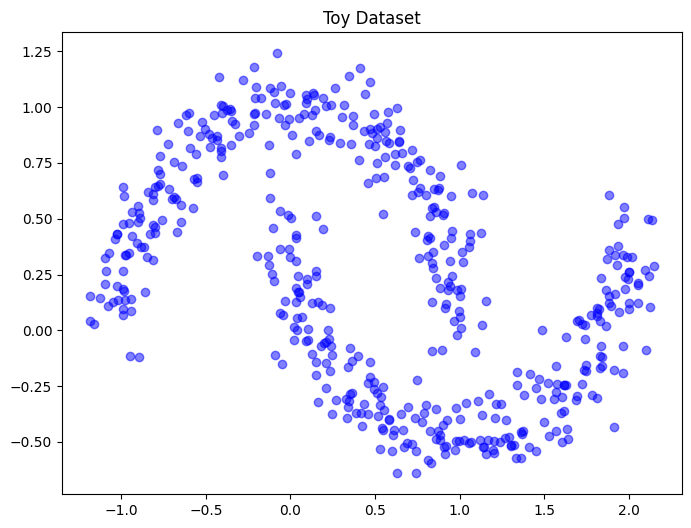

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Generate the Toy Dataset (Option C)
data_np, _ = make_moons(n_samples=500, noise=0.1)

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], alpha=0.5, color='blue')
plt.title("Toy Dataset")
plt.show()

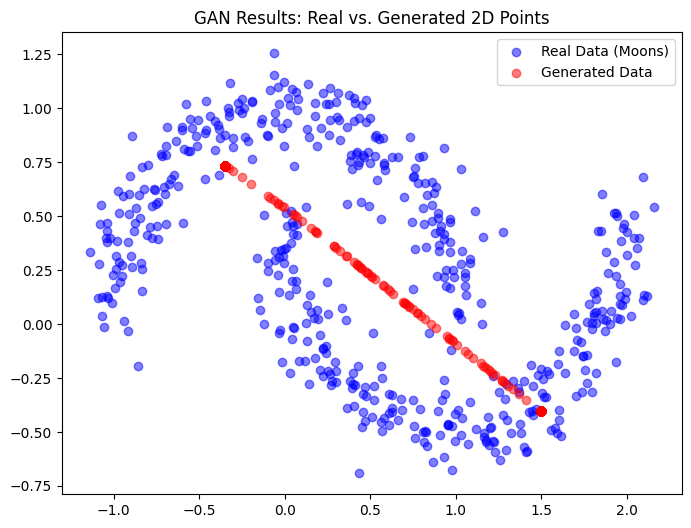

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# ==========================================
# (a) Generate and Visualize Toy Dataset
# ==========================================
# Using Option C: Two Moons
data_np, _ = make_moons(n_samples=500, noise=0.1)
real_data = torch.tensor(data_np, dtype=torch.float32)

# ==========================================
# (b) Train a Simple GAN
# ==========================================
latent_dim = 2  # The random noise dimension

# 1. Build the Generator (Noise -> 2D Point)
generator = nn.Sequential(
    nn.Linear(latent_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

# 2. Build the Discriminator (2D Point -> Real[1] or Fake[0])
discriminator = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

# Optimizers and Loss Function
lr = 0.005
opt_G = optim.Adam(generator.parameters(), lr=lr)
opt_D = optim.Adam(discriminator.parameters(), lr=lr)
criterion = nn.BCELoss()

# Training Loop
epochs = 2000
batch_size = 64

for epoch in range(epochs):
    # Randomly sample a batch of real data
    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real_batch = real_data[idx]
    
    # Generate a batch of fake data
    noise = torch.randn(batch_size, latent_dim)
    fake_batch = generator(noise)
    
    # ---------------------
    # Train Discriminator
    # ---------------------
    opt_D.zero_grad()
    # It should guess 1 (Real) for real data
    loss_D_real = criterion(discriminator(real_batch), torch.ones(batch_size, 1))
    # It should guess 0 (Fake) for fake data
    loss_D_fake = criterion(discriminator(fake_batch.detach()), torch.zeros(batch_size, 1))
    loss_D = loss_D_real + loss_D_fake
    loss_D.backward()
    opt_D.step()
    
    # ---------------------
    # Train Generator
    # ---------------------
    opt_G.zero_grad()
    # The generator wants to fool the D into guessing 1 (Real) for its fake data
    loss_G = criterion(discriminator(fake_batch), torch.ones(batch_size, 1))
    loss_G.backward()
    opt_G.step()

# ==========================================
# (c) Observe the Results (Plotting)
# ==========================================
# Generate final fake points to plot
with torch.no_grad():
    final_noise = torch.randn(500, latent_dim)
    generated_points = generator(final_noise).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], alpha=0.5, label="Real Data (Moons)", color="blue")
plt.scatter(generated_points[:, 0], generated_points[:, 1], alpha=0.5, label="Generated Data", color="red")
plt.title("GAN Results: Real vs. Generated 2D Points")
plt.legend()
plt.show()